In [45]:
# Ejecuta esta celda al inicio de tu notebook
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.preprocessing import MinMaxScaler, StandardScaler, LabelEncoder

In [46]:
# Configuracion de visualizacion
plt.style.use('seaborn-whitegrid')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

# Ejercicio 1: Carga y Exploración Inicial del Dataset

### Contexto: en proyectos de ciencia de datos, la calidad del dato de entrada determina directamente la validez de cualquier análisis o modelo predictivo. Estudios del sector estiman que aproximadamente el 80% del tiempo de trabajo de un científico de datos se dedica a preparar, limpiar y transformar datos, antes de realizar cualquier análisis o modelado.

In [47]:
df = pd.read_csv('encuesta_salud.csv')

In [48]:
df.shape

(500, 10)

In [49]:
df.dtypes

id                    int64
edad                float64
peso_kg             float64
talla_m             float64
presion_arterial    float64
colesterol          float64
glucosa             float64
grupo_sanguineo      object
region               object
diagnostico          object
dtype: object

In [50]:
df.isnull().sum()

id                   0
edad                45
peso_kg             60
talla_m              0
presion_arterial     0
colesterol          40
glucosa              0
grupo_sanguineo     25
region               0
diagnostico         30
dtype: int64

In [51]:
Q1 = df['talla_m'].quantile(0.25)
Q3 = df['talla_m'].quantile(0.75)
IQR = Q3 - Q1
lim_inf = Q1 - 1.5 * IQR
lim_sup = Q3 + 1.5 * IQR
outliers = df[(df['talla_m'] < lim_inf) | (df['talla_m'] > lim_sup)]

## resumen de observaciones:

### cuantas filas tiene el dataset

#### 10 filas

### cuantas columnas tiene

#### 500 columnas

### que tipos de datos hay

#### 1 entero, 6 flotantes y 3 objetos

### cuales columnas tienen valores faltantes.

#### id, talla_m, presion_Arterial, glucosa y region

### Identifica si algún valor de talla_m parece incorrecto observando los valores máximos y mínimos de esa columna.

In [52]:
print(outliers['talla_m'])

11    164.00
49    170.00
156     1.33
184   176.00
225   174.00
227   185.00
247   173.00
266   178.00
307   163.00
310     1.98
371   172.00
373   162.00
387     1.97
401   171.00
460   159.00
476   170.00
498   186.00
499   160.00
Name: talla_m, dtype: float64


# Ejercicio 2: Tratamiento de Valores Faltantes

## contexto: Una vez identificados los valores faltantes, debes decidir la estrategia más adecuada para cada columna. Esta decisión no es arbitraria: depende del porcentaje de NaN, del tipo de variable del objetivo del análisis.

In [53]:
df.isnull().sum()

id                   0
edad                45
peso_kg             60
talla_m              0
presion_arterial     0
colesterol          40
glucosa              0
grupo_sanguineo     25
region               0
diagnostico         30
dtype: int64

In [54]:
df['edad'] = df['edad'].fillna(df['edad'].median())
df['peso_kg'] = df['peso_kg'].fillna(df['peso_kg'].mean())

In [55]:
df['region'] = df['region'].fillna(df['region'].mode()[0])

In [56]:
df['talla_m'].describe()

count   500.00
mean      6.76
std      28.92
min       1.33
25%       1.61
50%       1.69
75%       1.75
max     186.00
Name: talla_m, dtype: float64

In [57]:
df.loc[df['talla_m'] > 3, 'talla_m'] = df['talla_m'] / 100

In [58]:
df.isnull().sum()

id                   0
edad                 0
peso_kg              0
talla_m              0
presion_arterial     0
colesterol          40
glucosa              0
grupo_sanguineo     25
region               0
diagnostico         30
dtype: int64

### Estrategia: edad -> mediana, peso_kg -> media, region -> moda

# Ejercicio 3: Detección y Manejo de Outliers

In [59]:
Q1 = df['presion_arterial'].quantile(0.25)
Q3 = df['presion_arterial'].quantile(0.75)
IQR = Q3 - Q1

lim_inf = Q1 - 1.5 * IQR
lim_sup = Q3 + 1.5 * IQR

print(f'Q1: {Q1:.1f} | Q3: {Q3:.1f} | IQR: {IQR:.1f}')
print(f'Limite inferior: {lim_inf:.1f}')
print(f'Limite superior: {lim_sup:.1f}')

Q1: 106.4 | Q3: 133.7 | IQR: 27.3
Limite inferior: 65.4
Limite superior: 174.7


In [60]:
outliers = df[(df['presion_arterial'] < lim_inf) | (df['presion_arterial'] > lim_sup)]

print(f'Outliers detectados: {len(outliers)}')
print(outliers[['id', 'presion_arterial', 'diagnostico']])

Outliers detectados: 15
      id  presion_arterial   diagnostico
47    48            260.00          Sano
49    50            220.00  Hipertension
71    72            275.00      Obesidad
108  109             62.20      Obesidad
148  149            275.00      Diabetes
260  261            290.00      Obesidad
300  301             64.50   Prediabetes
314  315            250.00           NaN
336  337             62.60  Hipertension
350  351            250.00  Hipertension
400  401            290.00  Hipertension
414  415            275.00          Sano
435  436            250.00      Obesidad
453  454            260.00      Obesidad
476  477            290.00      Obesidad


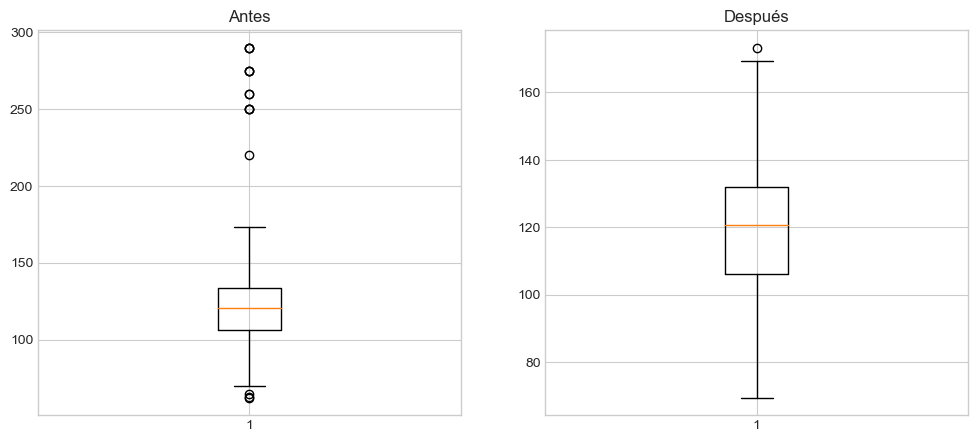

In [61]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Antes
axes[0].boxplot(df['presion_arterial'])
axes[0].set_title('Antes')

# Filtrar
df_limpio = df[(df['presion_arterial'] >= lim_inf) & (df['presion_arterial'] <= lim_sup)]

# Después
axes[1].boxplot(df_limpio['presion_arterial'])
axes[1].set_title('Después')

plt.show()

In [62]:
df = df_limpio.copy()

In [63]:
z_scores = np.abs(stats.zscore(df['glucosa']))

In [64]:
outliers_z = df[z_scores > 3]

print(f'Outliers por Z-Score: {len(outliers_z)}')
print(outliers_z[['id', 'glucosa']])

Outliers por Z-Score: 10
      id  glucosa
4      5   400.00
5      6   400.00
26    27   400.00
111  112   400.00
180  181   400.00
283  284   380.00
290  291   380.00
303  304   420.00
304  305   380.00
443  444   400.00


In [65]:
df = df[z_scores <= 3]

print(f'Filas restantes: {len(df)}')

Filas restantes: 475


# Ejercicio 4: Normalización de Variables Numéricas

In [66]:
cols_numericas = ['edad', 'peso_kg', 'talla_m', 'presion_arterial', 'colesterol', 'glucosa']

In [67]:
scaler_mm = MinMaxScaler()

df_minmax = df.copy()
df_minmax[cols_numericas] = scaler_mm.fit_transform(df[cols_numericas])

In [68]:
df_minmax[cols_numericas].describe().round(3)

,edad,peso_kg,talla_m,presion_arterial,colesterol,glucosa
count,475.00,475.00,475.00,475.00,437.00,475.00
mean,0.53,0.50,0.54,0.49,0.48,0.58
std,0.28,0.18,0.15,0.18,0.18,0.16
min,0.00,0.00,0.00,0.00,0.00,0.00
25%,0.33,0.40,0.43,0.36,0.36,0.46
50%,0.53,0.49,0.54,0.49,0.49,0.58
75%,0.77,0.61,0.65,0.60,0.61,0.70
max,1.00,1.00,1.00,1.00,1.00,1.00


### Se uso Min-Max Scaling para poner todas las variables en el rango de [0,1]

# Ejercicio 5: Codificación de Variables Categóricas

In [69]:
df_final = df_minmax.copy()

In [70]:
df_final = pd.get_dummies(df_final, columns=['region'], drop_first=True)
df_final = pd.get_dummies(df_final, columns=['grupo_sanguineo'], drop_first=True)

In [71]:
le = LabelEncoder()
df_final['diagnostico_cod'] = le.fit_transform(df_final['diagnostico'])

mapeo = dict(zip(le.classes_, le.transform(le.classes_)))
print(mapeo)

{'Diabetes': 0, 'Hipertension': 1, 'Obesidad': 2, 'Prediabetes': 3, 'Sano': 4, nan: 5}


# Ejercicio 6: Reporte Final y entregable.